# Training Analysis
Disease distribution plots and training loss curves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

In [2]:
# paths needed for plots
def find_project_root(marker: str = "delphi_labels_chapters_colours_icd.csv") -> Path:
    """Walk upward from cwd until we find a known project file."""
    candidate = Path().resolve()
    for _ in range(6):
        if (candidate / marker).exists():
            return candidate
        candidate = candidate.parent
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}')")

ROOT        = find_project_root()
DATA_DIR    = ROOT / "data" / "ukb_simulated_data"
LABELS_PATH = ROOT / "delphi_labels_chapters_colours_icd.csv"
FIG_DIR     = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

# wandb config (set before running) 
WANDB_PROJECT = "Delphi"          # wandb project name
WANDB_RUN_ID  = "delphi"              # set to a specific run ID, or None to use latest

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})



In [3]:
# load the data
train = np.memmap(DATA_DIR / "train.bin", dtype=np.uint32, mode="r").reshape(-1, 3)
val   = np.memmap(DATA_DIR / "val.bin",   dtype=np.uint32, mode="r").reshape(-1, 3)

# token IDs are in column 2
train_tokens = train[:, 2]
val_tokens   = val[:, 2]
all_tokens   = np.concatenate([train_tokens, val_tokens])

In [4]:
labels = pd.read_csv(LABELS_PATH)

# Keep only ICD-10 disease tokens (exclude Technical, Sex, Lifestyle)
EXCLUDED_CHAPTERS = {"Technical", "Sex", "Smoking, Alcohol and BMI"}
disease_labels = labels[~labels["ICD-10 Chapter (short)"].isin(EXCLUDED_CHAPTERS)].copy()
disease_labels = disease_labels.dropna(subset=["ICD-10 Chapter (short)"])

# count events per token in the synthetic data
token_counts = pd.Series(all_tokens).value_counts().rename("events_in_data")
disease_labels = disease_labels.merge(
    token_counts.reset_index().rename(columns={"index": "index", "events_in_data": "events_in_data"}),
    on="index", how="left"
)
disease_labels["events_in_data"] = disease_labels["events_in_data"].fillna(0).astype(int)
disease_labels["present"] = disease_labels["events_in_data"] > 0

# for disease plots

chapters = disease_labels.groupby("ICD-10 Chapter (short)")

chapter_stats = chapters.agg(
    total_diseases   = ("index",          "count"),
    present_diseases = ("present",        "sum"),
    total_events     = ("events_in_data", "sum"),
).reset_index()

# colour per chapter 
chapter_color = (
    disease_labels.groupby("ICD-10 Chapter (short)")["color"]
    .first()
    .reset_index()
    .rename(columns={"color": "color"})
)
chapter_stats = chapter_stats.merge(chapter_color, on="ICD-10 Chapter (short)")
chapter_stats = chapter_stats.sort_values("total_events", ascending=False)

short_names = {c: c.split(". ", 1)[-1] if ". " in c else c
               for c in chapter_stats["ICD-10 Chapter (short)"]}
chapter_stats["chapter_short"] = chapter_stats["ICD-10 Chapter (short)"].map(short_names)

## Figure 1 — Diseases per chapter: present vs total

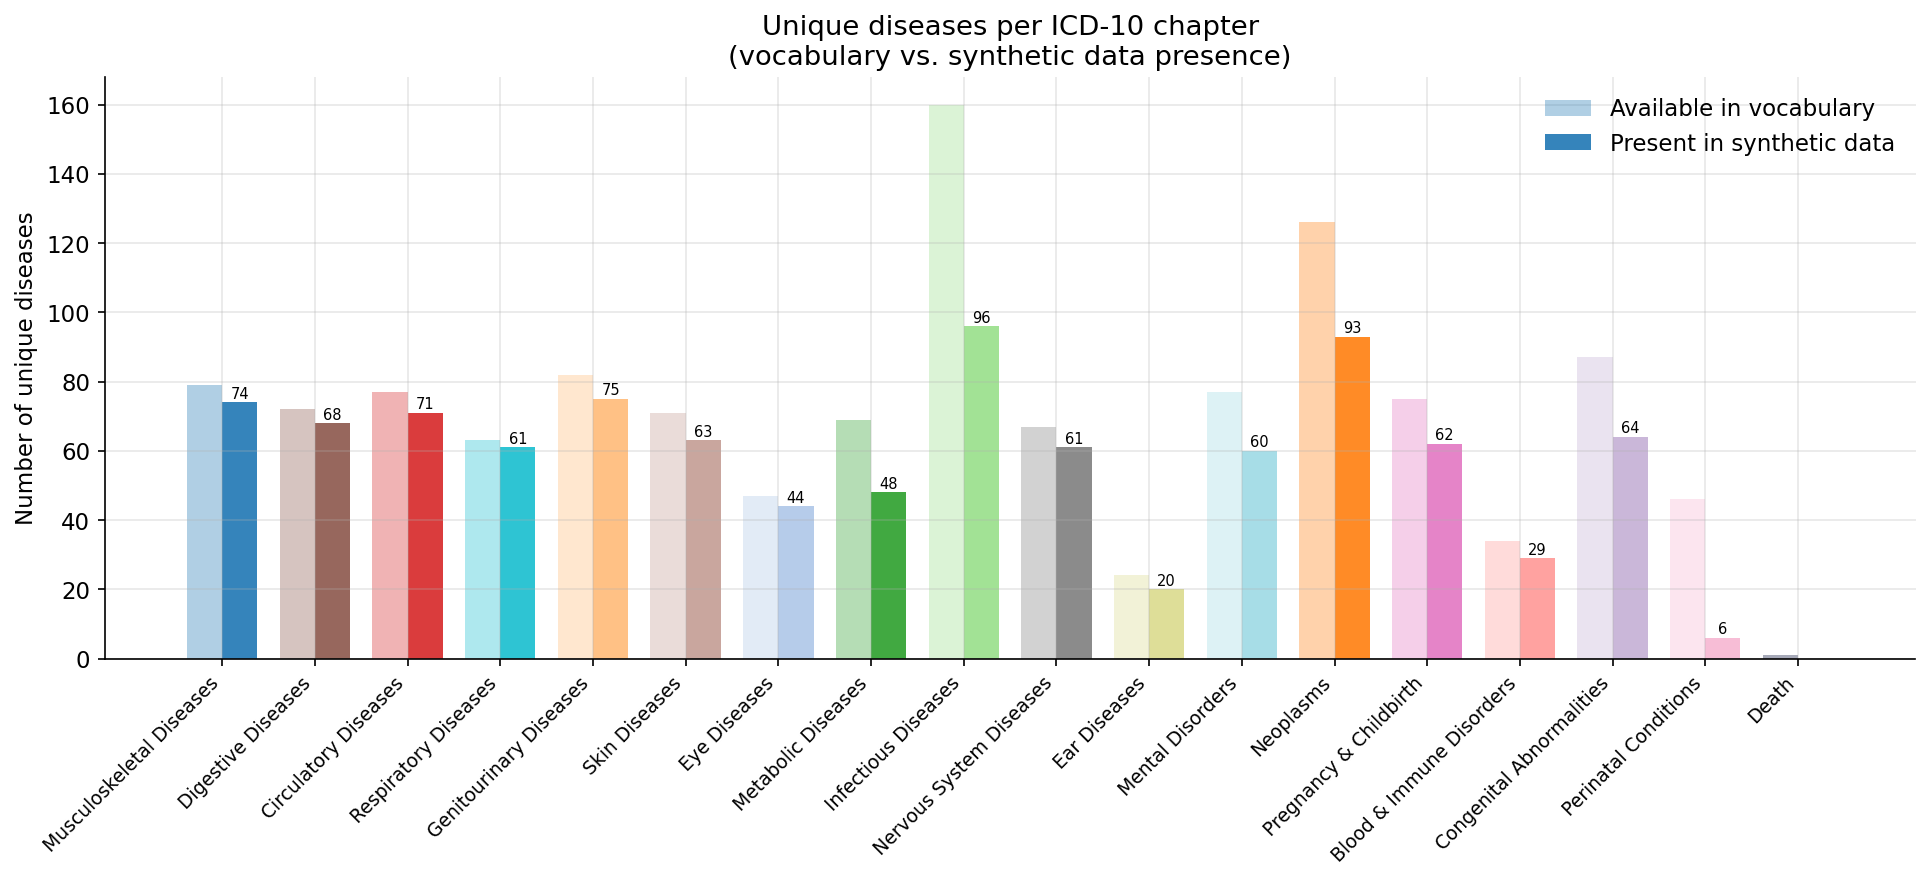

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

x   = np.arange(len(chapter_stats))
w   = 0.38
colors = chapter_stats["color"].tolist()

bars_total   = ax.bar(x - w/2, chapter_stats["total_diseases"],   width=w,
                      color=colors, alpha=0.35, label="Available in vocabulary")
bars_present = ax.bar(x + w/2, chapter_stats["present_diseases"], width=w,
                      color=colors, alpha=0.9,  label="Present in synthetic data")

ax.set_xticks(x)
ax.set_xticklabels(chapter_stats["chapter_short"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Number of unique diseases")
ax.set_title("Unique diseases per ICD-10 chapter\n(vocabulary vs. synthetic data presence)")
ax.legend(frameon=False)

for bar, val in zip(bars_present, chapter_stats["present_diseases"]):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(int(val)), ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_diseases_per_chapter.png", bbox_inches="tight")
plt.show()

## Figure 2 — Total events per chapter

/tmp/ipykernel_1764241/2388690013.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(chapter_stats["chapter_short"], rotation=45, ha="right", fontsize=9)


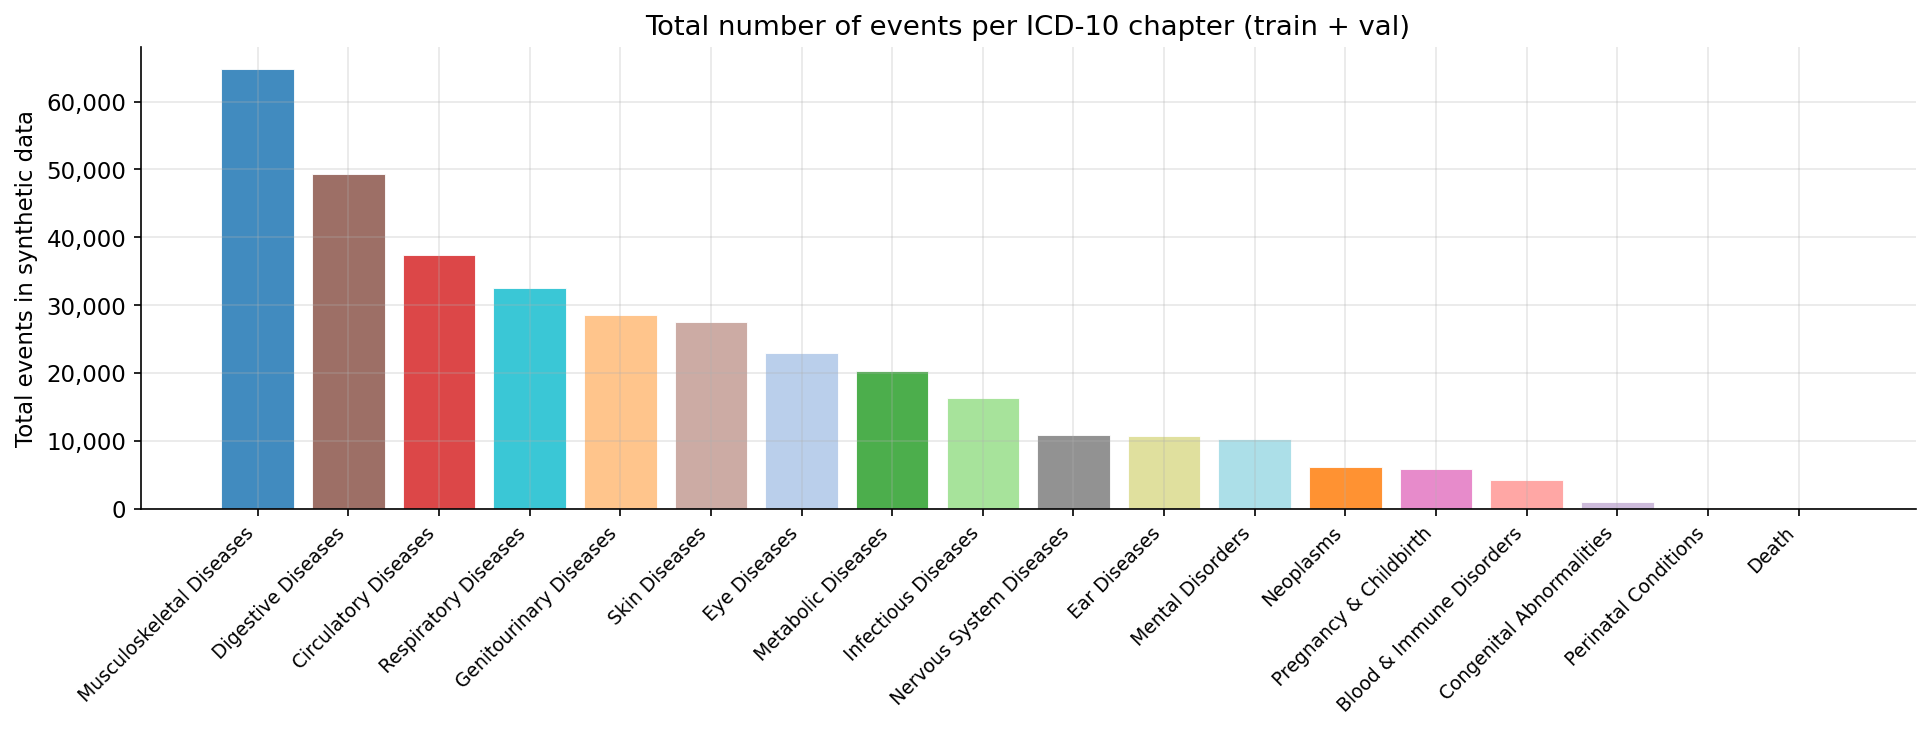

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(chapter_stats["chapter_short"], chapter_stats["total_events"],
       color=chapter_stats["color"], alpha=0.85, edgecolor="white", linewidth=0.5)

ax.set_xticklabels(chapter_stats["chapter_short"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Total events in synthetic data")
ax.set_title("Total number of events per ICD-10 chapter (train + val)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_events_per_chapter.png", bbox_inches="tight")
plt.show()

## Figure 3 — Top diseases by number of events

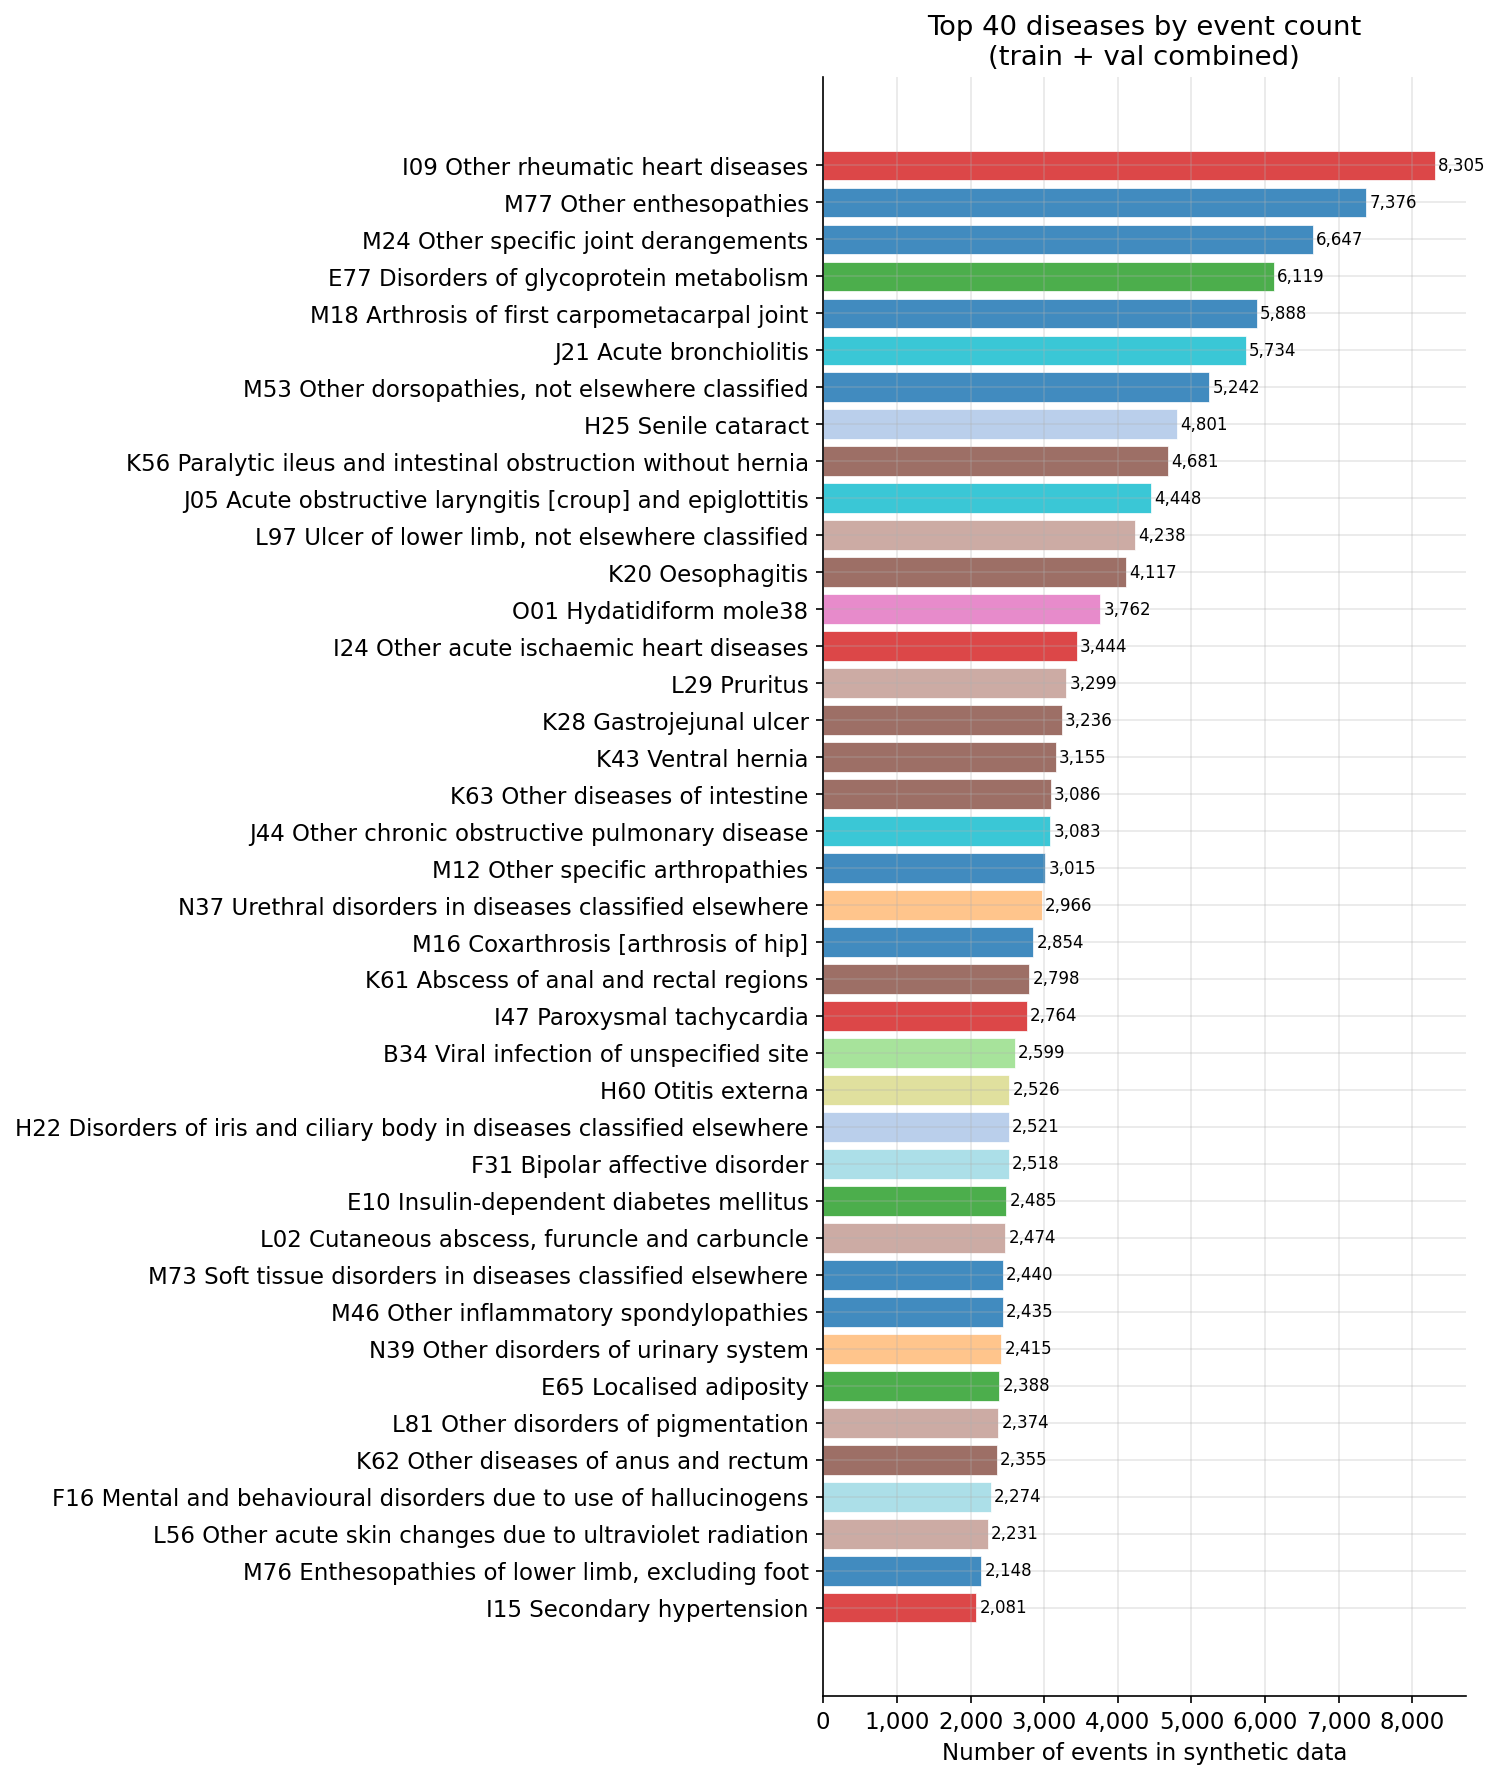

In [7]:
TOP_N = 40 #changeable if desired 

top_diseases = (
    disease_labels[disease_labels["present"]]
    .sort_values("events_in_data", ascending=False)
    .head(TOP_N)
)

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(
    top_diseases["name"],
    top_diseases["events_in_data"],
    color=top_diseases["color"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
ax.invert_yaxis()
ax.set_xlabel("Number of events in synthetic data")
ax.set_title(f"Top {TOP_N} diseases by event count\n(train + val combined)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, val in zip(bars, top_diseases["events_in_data"]):
    ax.text(bar.get_width() + ax.get_xlim()[1] * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_top_diseases.png", bbox_inches="tight")
plt.show()


## Figure 4 — Training curves

In [8]:

def load_group_histories(project: str, base_name: str) -> list[pd.DataFrame]:
    """Load all fold runs matching base_name (by group or name prefix)."""
    import wandb
    api      = wandb.Api()
    all_runs = list(api.runs(project))
    runs     = [r for r in all_runs
                if r.group == base_name or r.name.startswith(base_name + "_")]
    if not runs:
        available = sorted(set(r.group or r.name for r in all_runs))
        raise ValueError(
            f"No runs found for '{base_name}' in '{project}'.\n"
            f"Available: {available}"
        )
    histories = []
    for r in sorted(runs, key=lambda r: r.name):
        h = r.history(pandas=True)
        if "_step" in h.columns:
            h = h.rename(columns={"_step": "step"})
        h["fold"] = r.name
        histories.append(h)
    print(f"'{base_name}': {len(histories)} folds loaded")
    return histories


def interpolate_to_common_grid(series_list: list, n_points: int = 300):
    x_min = max(s.dropna().index[0]  if len(s.dropna()) else 0 for s in series_list)
    x_max = min(s.dropna().index[-1] if len(s.dropna()) else 0 for s in series_list)
    grid  = np.linspace(x_min, x_max, n_points)
    mat   = np.array([np.interp(grid, s.dropna().index, s.dropna().values)
                      for s in series_list])
    return grid, mat


def robust_band(mat):
    """Return median and IQR-based band (robust to outlier folds/spikes)."""
    median = np.median(mat, axis=0)
    q25    = np.percentile(mat, 25, axis=0)
    q75    = np.percentile(mat, 75, axis=0)
    return median, q25, q75


def smooth_series(s: pd.Series, w: int = 15) -> pd.Series:
    return s.rolling(w, min_periods=1, center=True).mean()


def find_col(h: pd.DataFrame, candidates: list) -> str | None:
    return next((c for c in candidates if c in h.columns), None)


In [9]:
# set the model names before running
MODELS = {
    "Delphi":   WANDB_RUN_ID,          # emb_path = None  
    "General Mode": "ours_m1",  # replace with your base run name (general model )
    "Medical Model": "ours_m2",  # replace with your base run name (medical model )
}

MODEL_COLORS = ["#1f77b4", "#2ca02c" ,"#9467bd"]   

LOSS_DEFS = [
    ("Total loss $\\mathcal{L}$",
     "train/agg_loss", "val/loss"),
    ("Classification $\\mathcal{L}_{CE}$",
     "train/loss_ce",  "val/loss_ce"),
    ("Temporal $\\mathcal{L}_{DT}$",
     "train/loss_dt",  "val/loss_dt"),
]

VAL_CANDIDATES = {
    "val/loss":    ["val/loss",    "val/agg_loss"],
    "val/loss_ce": ["val/loss_ce", "val/loss_j"],
    "val/loss_dt": ["val/loss_dt", "val/loss_T"],
}

In [10]:
# load all train folds for each model 
all_models_histories = {}
for model_label, base_name in MODELS.items():
    if base_name.startswith("placeholder"):
        print(f"Skipping '{model_label}' — placeholder not set")
        continue
    try:
        all_models_histories[model_label] = load_group_histories(WANDB_PROJECT, base_name)
    except Exception as e:
        print(f"Could not load '{model_label}': {e}")



wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/maria/.netrc.


'delphi': 10 folds loaded
'ours_m1': 10 folds loaded
'ours_m2': 10 folds loaded


/tmp/ipykernel_1764241/1811527330.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


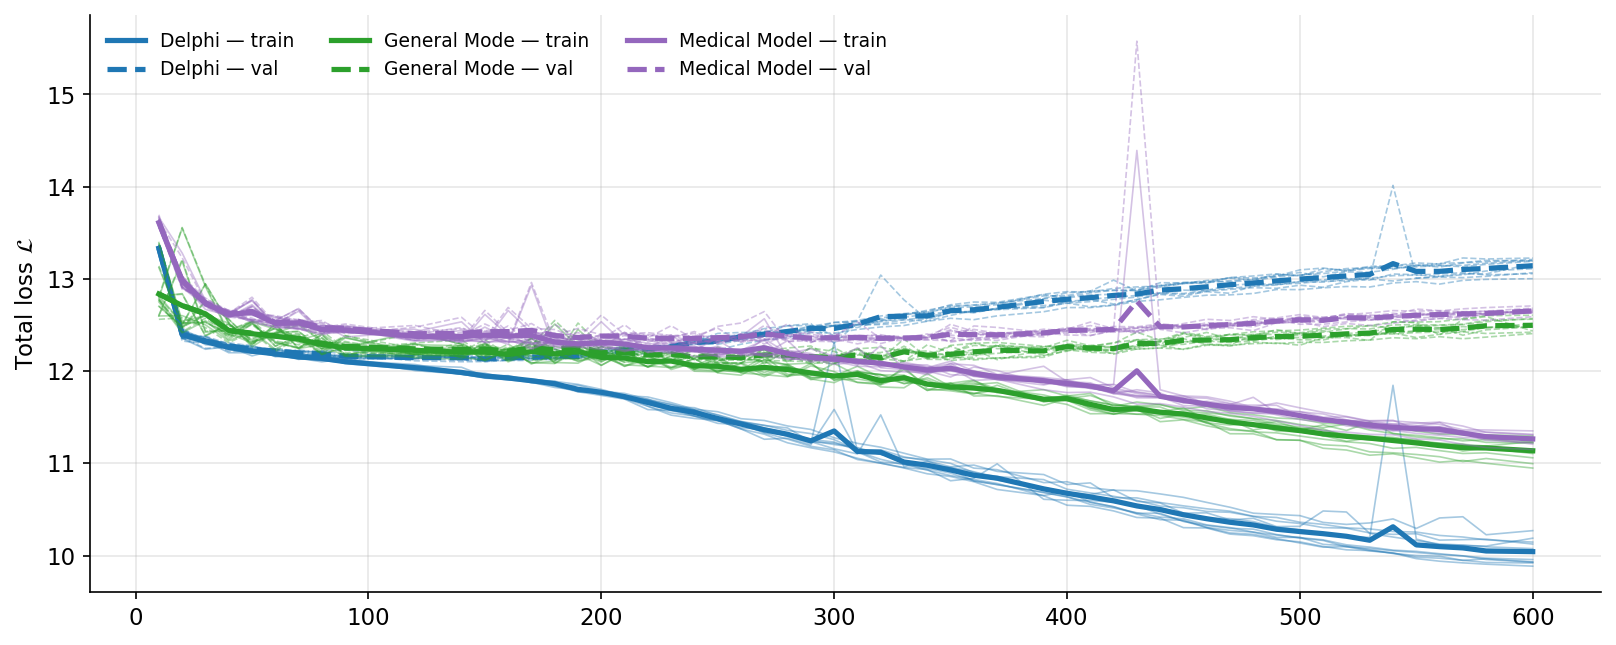

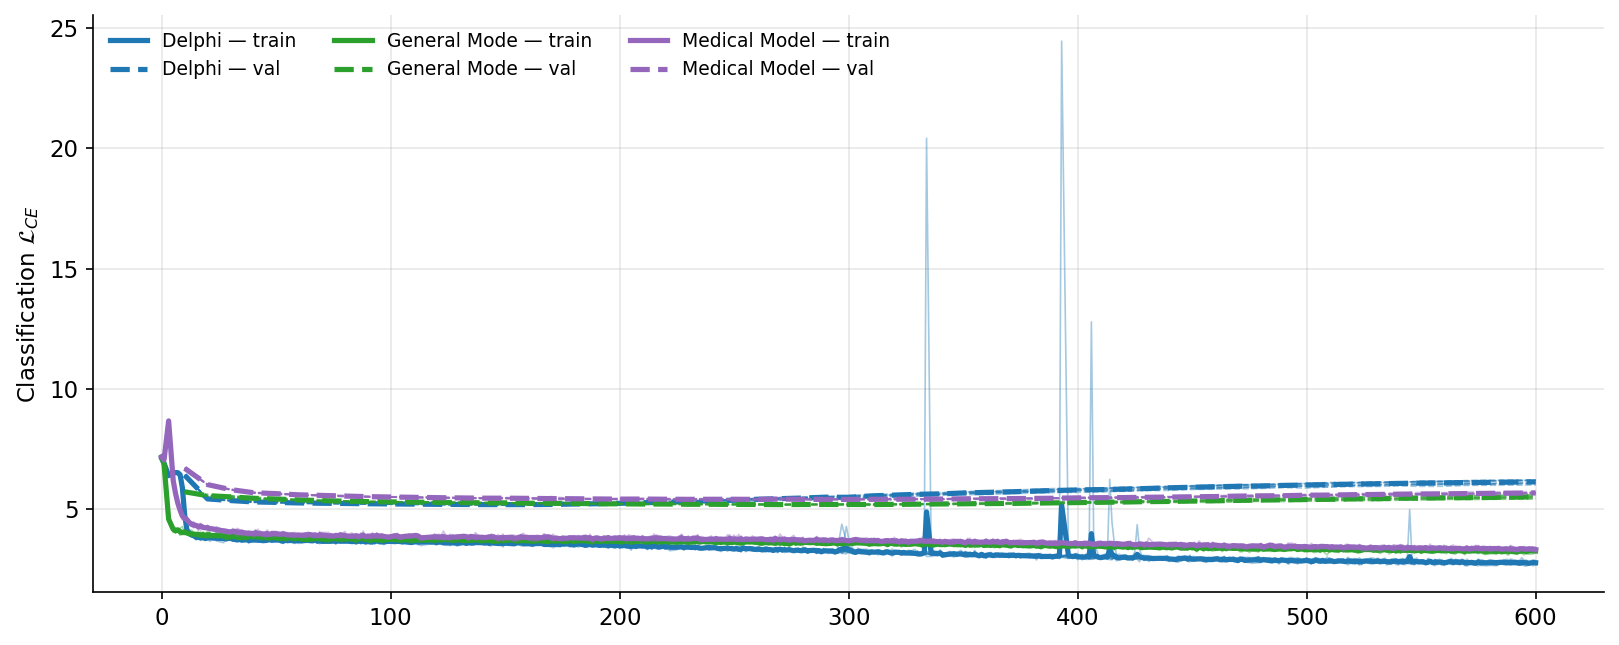

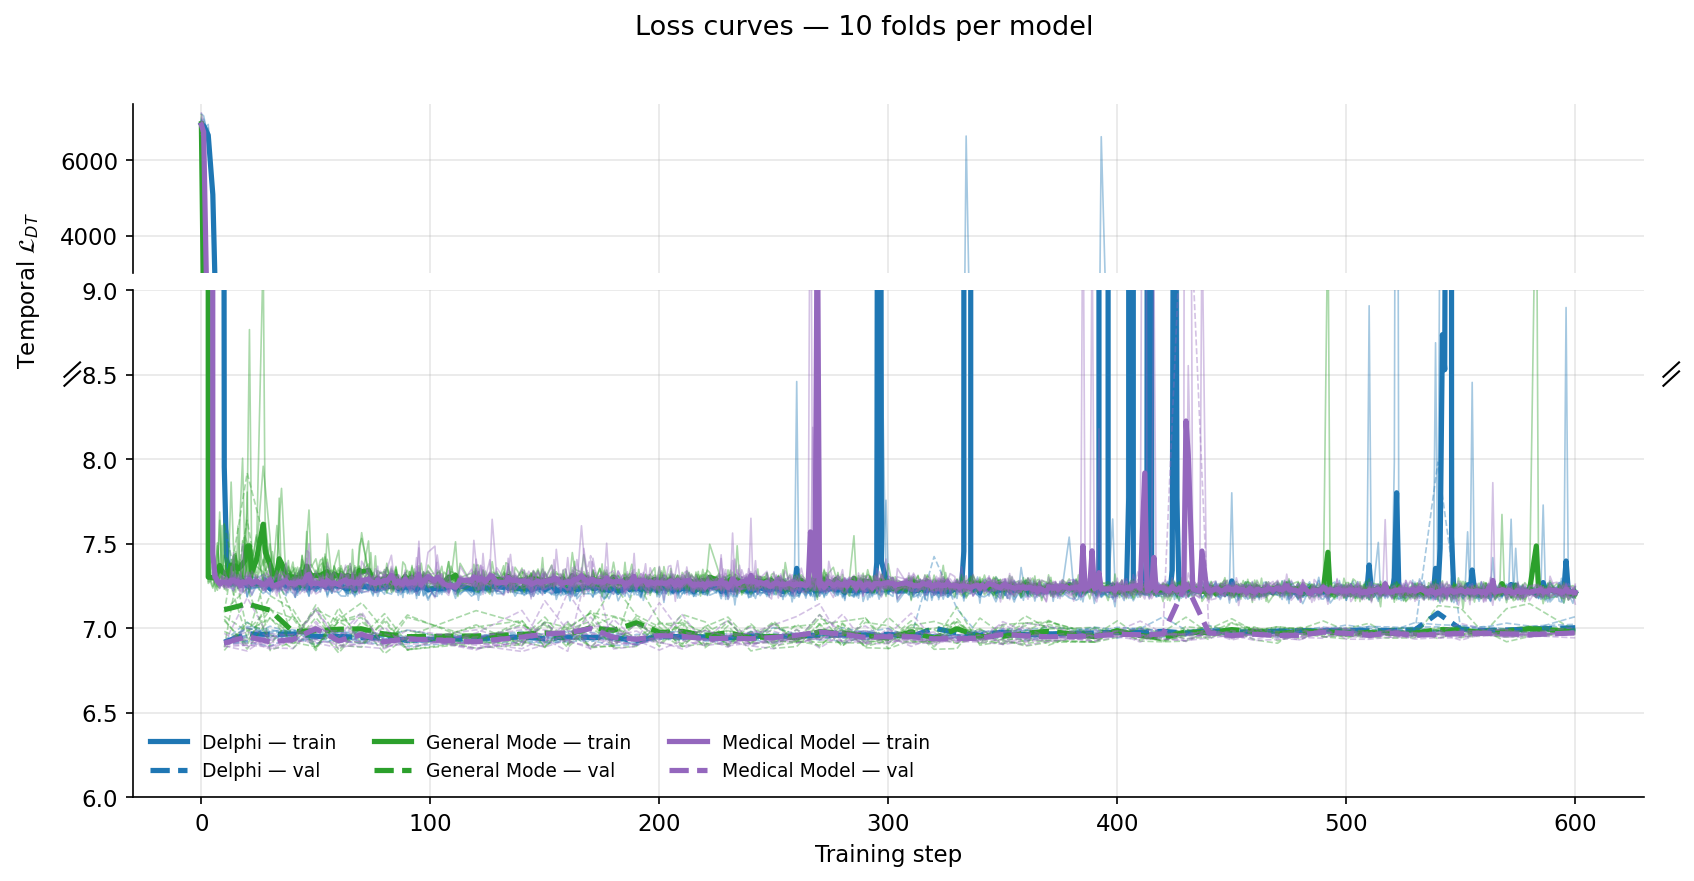

In [11]:
if all_models_histories:

    for row_idx, (loss_title, train_col, val_col) in enumerate(LOSS_DEFS):

        # broken axis for the last metric 
        if row_idx == 2:
            fig, (ax_top, ax_bot) = plt.subplots(
                2, 1, figsize=(13, 6), sharex=True,
                gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05}
            )
            BREAK_THRESHOLD = 9   
            TOP_YLIM        = (3000, 7500)  
            BOT_YLIM        = (6, BREAK_THRESHOLD)
            ax = ax_bot          
        else:
            fig, ax = plt.subplots(1, 1, figsize=(13, 5))

        for (model_label, fold_hists), color in zip(all_models_histories.items(),
                                                     MODEL_COLORS):
            for col_key, ls, alpha_fold, alpha_band, suffix in [
                (train_col, "-",  0.3, 0.12, "train"),
                (val_col,   "--", 0.3, 0.12, "val"),
            ]:
                series = []
                for h in fold_hists:
                    col = find_col(h, [col_key])
                    if col is None:
                        continue
                    s = h.set_index("step")[col].dropna()
                    series.append(s)

                if not series:
                    continue

                aligned = pd.concat([s.reset_index(drop=True) for s in series], axis=1)
                mean    = aligned.mean(axis=1)
                x_axis  = series[0].index

                if row_idx == 2:
                    for s in series:
                        ax_top.plot(s.index, s.values, color=color, alpha=0.4, lw=0.8, ls=ls)
                        ax_bot.plot(s.index, s.values, color=color, alpha=0.4, lw=0.8, ls=ls)
                    ax_top.plot(x_axis, mean.values, color=color, lw=2.5, ls=ls)
                    ax_bot.plot(x_axis, mean.values, color=color, lw=2.5, ls=ls,
                                label=f"{model_label} — {suffix}")
                else:
                    for s in series:
                        ax.plot(s.index, s.values, color=color, alpha=0.4, lw=0.8, ls=ls)
                    ax.plot(x_axis, mean.values, color=color, lw=2.5, ls=ls,
                            label=f"{model_label} — {suffix}")

        if row_idx == 2:
            ax_top.set_ylim(*TOP_YLIM)
            ax_bot.set_ylim(*BOT_YLIM)

            # Marcas de corte (diagonal)
            d = 0.008
            kw = dict(transform=fig.transFigure, color="k", clip_on=False, lw=1)
            for x_pos in [0.09, 0.91]:          # izquierda y derecha del área
                fig.add_artist(plt.Line2D([x_pos, x_pos + d],
                                          [0.585 - d, 0.585 + d], **kw))
                fig.add_artist(plt.Line2D([x_pos, x_pos + d],
                                          [0.575 - d, 0.575 + d], **kw))

            ax_top.spines["bottom"].set_visible(False)
            ax_bot.spines["top"].set_visible(False)
            ax_top.tick_params(bottom=False)

            ax_bot.set_ylabel(loss_title, fontsize=11)
            ax_bot.yaxis.set_label_coords(-0.06, 1.0)   # centra el ylabel en ambos ejes
            ax_bot.legend(frameon=False, fontsize=9, ncol=len(all_models_histories))
            ax_bot.set_xlabel("Training step")
            ax_bot.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        else:
            ax.set_ylabel(loss_title, fontsize=11)
            ax.legend(frameon=False, fontsize=9, ncol=len(all_models_histories))
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
            if row_idx == 2:
                ax.set_xlabel("Training step")

    n_folds = len(next(iter(all_models_histories.values())))
    fig.suptitle(f"Loss curves — {n_folds} folds per model", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig4_loss_curves.png", bbox_inches="tight")
    plt.show()

## Figure 5 — Boxplot

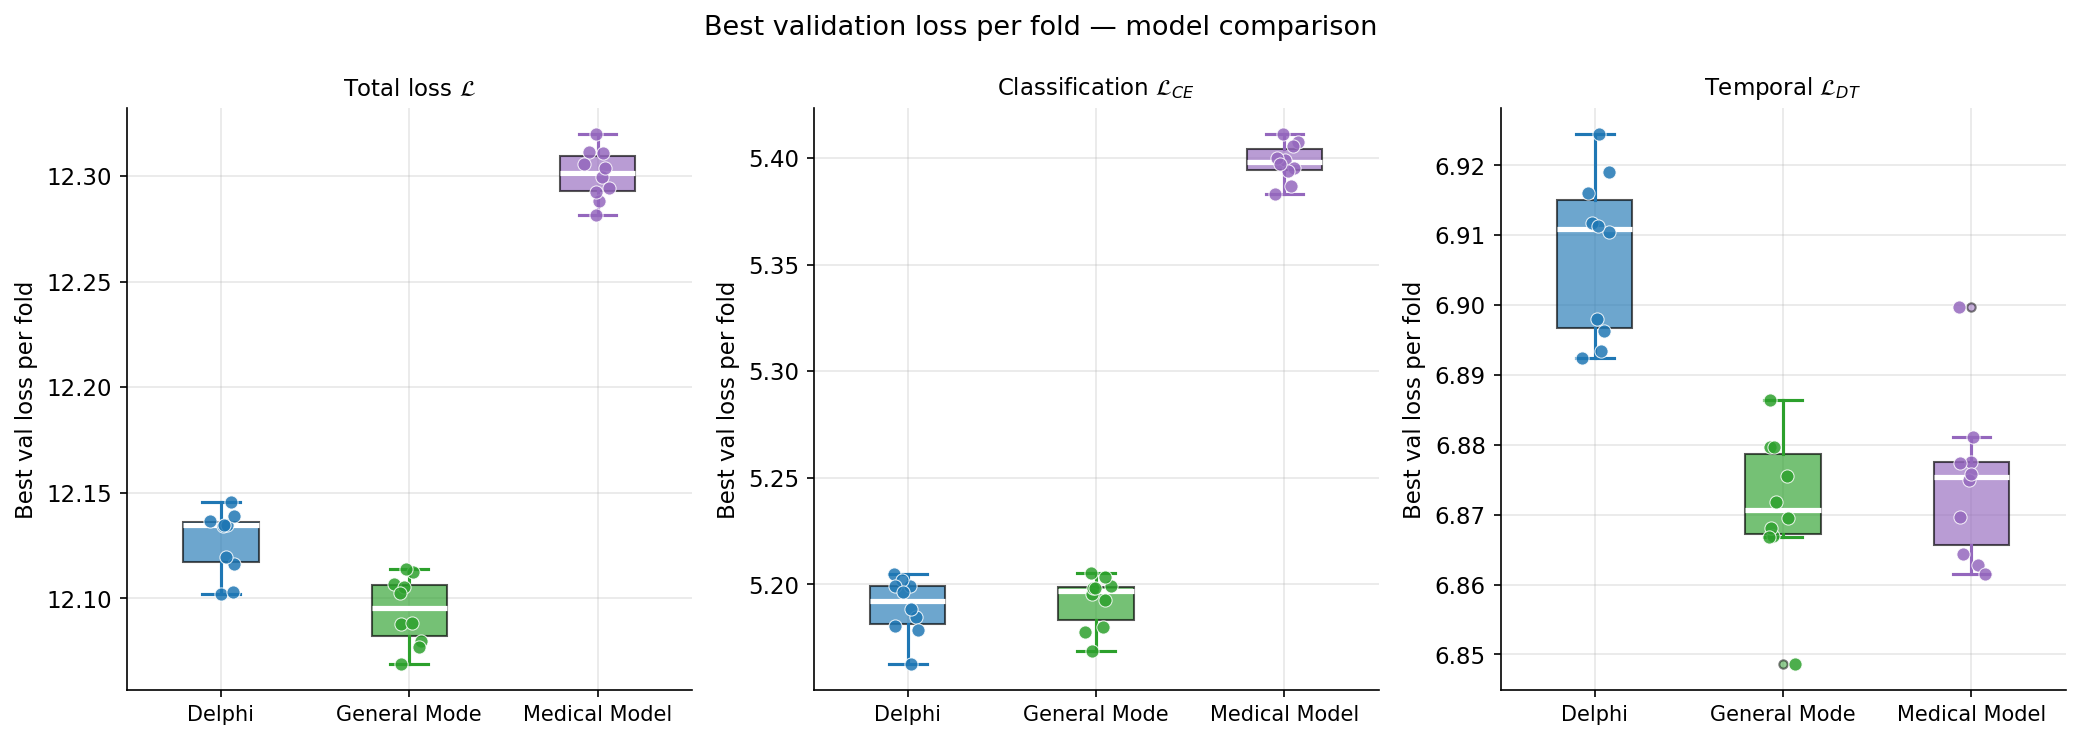

In [12]:
if all_models_histories:

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    for ax, (loss_title, _, val_col) in zip(axes, LOSS_DEFS):
        candidates = VAL_CANDIDATES[val_col]

        positions = []
        tick_labels = []
        all_data = []

        for pos_idx, (model_label, fold_hists) in enumerate(
                all_models_histories.items(), start=1):
            color = MODEL_COLORS[pos_idx - 1]

            # one point per fold = best (min) val loss of that fold
            best_per_fold = []
            for h in fold_hists:
                col = find_col(h, candidates)
                if col and h[col].dropna().shape[0] > 0:
                    best_per_fold.append(h[col].dropna().min())

            if not best_per_fold:
                continue

            data = np.array(best_per_fold)
            positions.append(pos_idx)
            tick_labels.append(model_label)
            all_data.append((data, color))

            ax.boxplot(
                data, positions=[pos_idx], patch_artist=True, widths=0.4,
                medianprops=dict(color="white", linewidth=2.5),
                boxprops=dict(facecolor=color, alpha=0.65),
                whiskerprops=dict(color=color, lw=1.5),
                capprops=dict(color=color, lw=1.5),
                flierprops=dict(marker="o", markerfacecolor=color,
                                markersize=4, alpha=0.5, linestyle="none"),
            )
            jitter = np.random.uniform(-0.08, 0.08, size=len(data))
            ax.scatter(pos_idx + jitter, data, color=color,
                       alpha=0.85, s=40, zorder=4, edgecolors="white", lw=0.5)

        ax.set_xticks(positions)
        ax.set_xticklabels(tick_labels, fontsize=10)
        ax.set_ylabel("Best val loss per fold")
        ax.set_title(loss_title, fontsize=11)

    fig.suptitle("Best validation loss per fold — model comparison", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig5_val_loss_boxplots.png", bbox_inches="tight")
    plt.show()